In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('C:/Users/hp/Downloads/Python/ecommerce_customer_churn_dataset.csv')
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [3]:
df.shape

(50000, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [5]:
#checking for null values
df.isnull().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [6]:
#checking for duplicates
print('Duplicates:',df.duplicated().sum())

Duplicates: 0


In [7]:
cols = ['Age', 'Login_Frequency', 'Wishlist_Items', 'Days_Since_Last_Purchase', 'Customer_Service_Calls', 'Product_Reviews_Written',
        'Payment_Method_Diversity']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[cols] = df[cols].round()
df[cols] = df[cols].astype('Int64')

In [8]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43,Male,France,Marseille,2.9,14,27.4,6.0,50.6,3,...,17.9,9,4,16.3,20.8,1,953.33,2278.0,0,Q1
1,36,Male,UK,Manchester,1.6,15,42.7,10.3,37.7,1,...,42.8,7,3,NaN,23.3,3,1067.47,3028.0,0,Q4
2,45,Female,Canada,Vancouver,2.9,10,24.8,1.6,70.9,1,...,0.0,4,1,NaN,8.8,<NA>,1289.75,2317.0,0,Q4
3,56,Female,USA,New York,2.6,10,38.4,14.8,41.7,9,...,41.4,2,5,85.9,31.0,3,2340.92,2674.0,0,Q1
4,35,Male,India,Delhi,3.1,29,51.4,NaN,19.1,9,...,37.9,1,11,83.0,50.4,4,3041.29,5354.0,0,Q4


In [9]:
X = df.drop('Churned', axis=1)
y = df['Churned']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [10]:
print('X_train:',X_train.shape)
print('X_test:',X_test.shape)
print('y_train:',y_train.shape)
print('y_test:',y_test.shape)

X_train: (40000, 24)
X_test: (10000, 24)
y_train: (40000,)
y_test: (10000,)


In [11]:
train_df = X_train.copy()
train_df['Churned'] = y_train.values

### Business KPIs

1. Overall churn rate - 
The overall churn rate indicates the proportion of customers discontinuing service

In [12]:
churn_rate = train_df['Churned'].mean()
print(f"Overall Churn Rate: {churn_rate:.2%}")

Overall Churn Rate: 28.90%


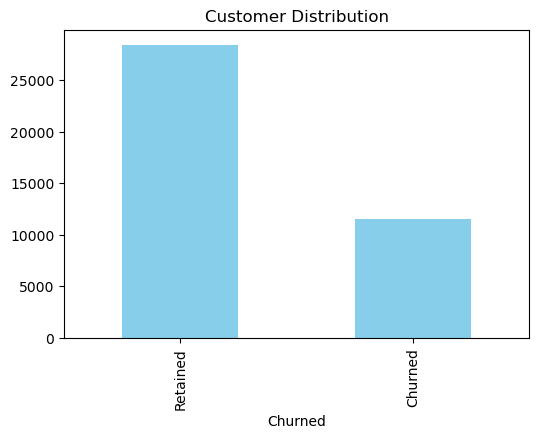

In [13]:
plt.figure(figsize=(6,4))
customer_counts = train_df['Churned'].value_counts().rename(
    {0: 'Retained', 1: 'Churned'})
customer_counts.plot(kind='bar', color='skyblue')
plt.title('Customer Distribution')
plt.show()

2. Revenue at Risk - Total LTV (lifetime value) lost due to churn - total lifetime value of churned customers

In [14]:
revenue_at_risk = train_df.loc[train_df['Churned'] == 1, 'Lifetime_Value'].sum()
print(f"Revenue at Risk: {revenue_at_risk:,.2f}")

Revenue at Risk: 16,531,475.70


In [15]:
# %revenue at risk
total_revenue = train_df['Lifetime_Value'].sum()
revenue_risk_pct = revenue_at_risk / total_revenue
print(f"Revenue at Risk (%): {revenue_risk_pct:.2%}")

Revenue at Risk (%): 28.68%


3. Average LTV: Churned vs Retained

In [16]:
ltv_by_churn = train_df.groupby('Churned')['Lifetime_Value'].mean()
ltv_by_churn.rename({0: 'Retained', 1: 'Churned'})

Churned
Retained    1445.840323
Churned     1430.058452
Name: Lifetime_Value, dtype: float64

In [ ]:
# almost same for churned and retained

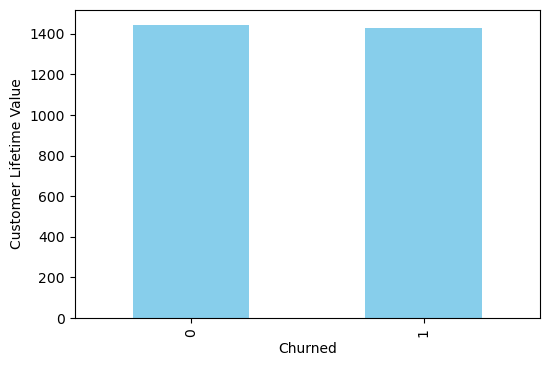

In [17]:
plt.figure(figsize=(6,4))
ltv_by_churn.plot(kind='bar', color='skyblue')
plt.ylabel('Customer Lifetime Value')
plt.show()

4. Engagement KPIs

In [18]:
#Average engagement metrics by churn
engagement_cols = ['Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Mobile_App_Usage']
train_df.groupby('Churned')[engagement_cols].mean()

,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Mobile_App_Usage
Churned,,,,
0,12.652496,29.235056,9.298703,20.720537
1,9.147059,23.755296,7.381821,16.117291


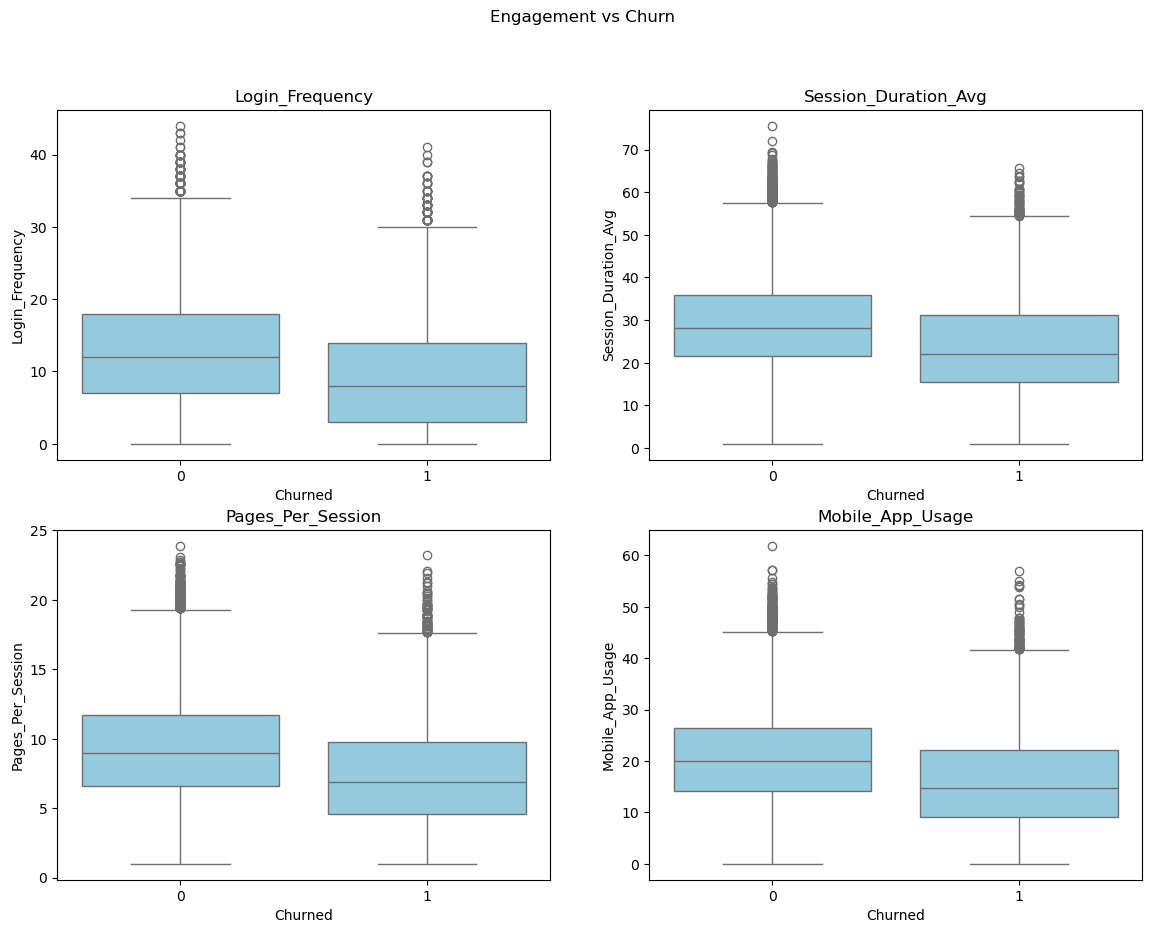

In [19]:
plt.figure(figsize=(14,10))
i = 1

for col in engagement_cols:
    plt.subplot(2,2,i)
    sns.boxplot(data=train_df, x='Churned', y=col, color='skyblue')
    plt.title(col)
    i+=1
plt.suptitle('Engagement vs Churn')
plt.show()

5. Recency KPI (days since last purchase)

In [20]:
recency_kpi = train_df.groupby('Churned')['Days_Since_Last_Purchase'].mean()
recency_kpi.rename({0: 'Retained', 1: 'Churned'})

Churned
Retained    26.880372
Churned     36.773961
Name: Days_Since_Last_Purchase, dtype: Float64

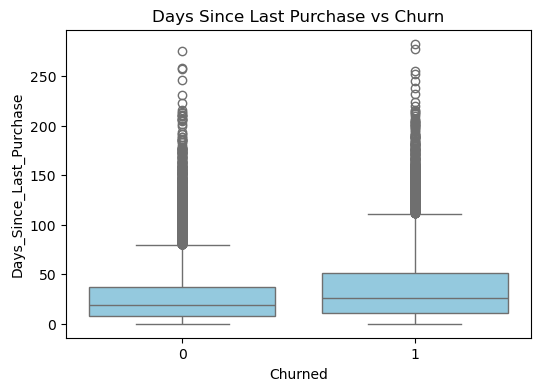

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train_df, x='Churned', y='Days_Since_Last_Purchase', color='skyblue')
plt.title('Days Since Last Purchase vs Churn')
plt.show()

6. Purchase behaviour

In [22]:
purchase_kpis = ['Total_Purchases','Average_Order_Value','Cart_Abandonment_Rate','Discount_Usage_Rate']
train_df.groupby('Churned')[purchase_kpis].mean()

,Total_Purchases,Average_Order_Value,Cart_Abandonment_Rate,Discount_Usage_Rate
Churned,,,,
0,13.830911,118.609652,54.169490,43.006646
1,11.382855,135.187847,64.124785,39.386927


In [ ]:
# avg_order val more for churned customers

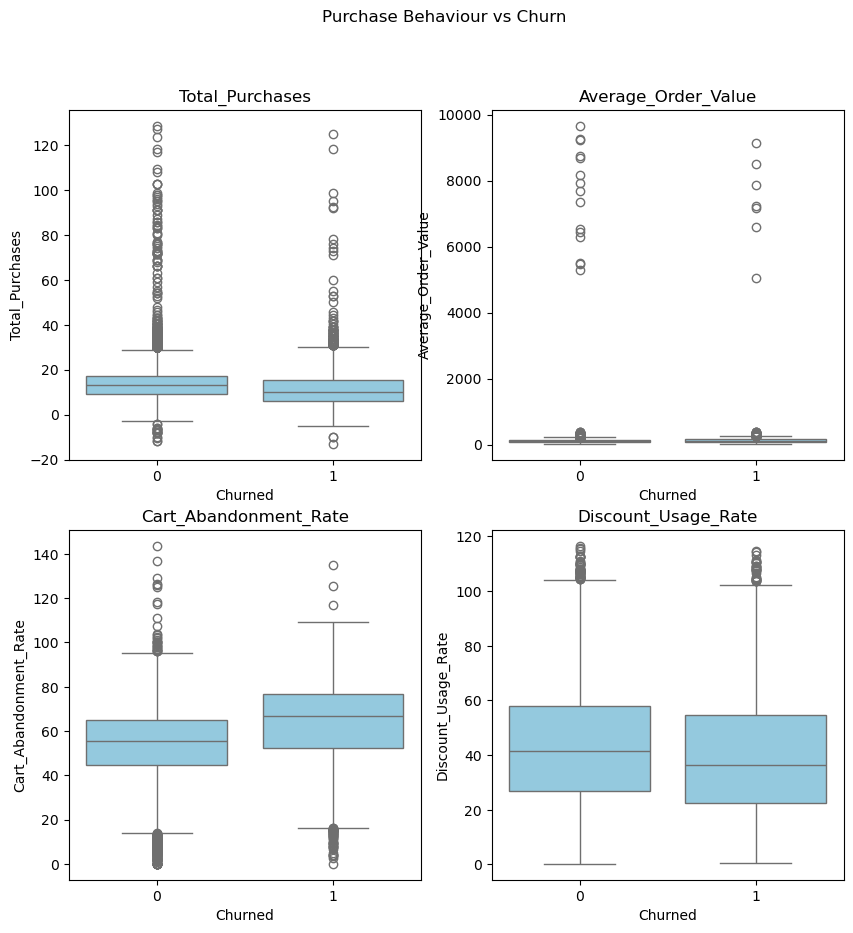

In [69]:
plt.figure(figsize=(10,10))
i = 1

for col in purchase_kpis:
    plt.subplot(2,2,i)
    sns.boxplot(data=train_df, x='Churned', y=col, color='skyblue')
    plt.title(col)
    i+=1
plt.suptitle('Purchase Behaviour vs Churn')
plt.show()

7. Customer Experience KPIs

In [24]:
experience_kpis = ['Customer_Service_Calls','Returns_Rate','Product_Reviews_Written']
train_df.groupby('Churned')[experience_kpis].mean()

,Customer_Service_Calls,Returns_Rate,Product_Reviews_Written
Churned,,,
0,5.189228,6.487451,3.124835
1,6.891032,7.208367,2.201754


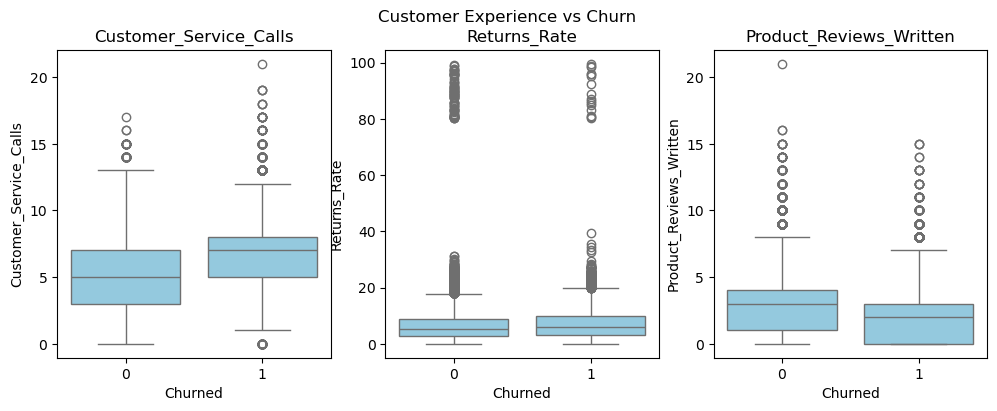

In [25]:
plt.figure(figsize=(12,4))
i = 1

for col in experience_kpis:
    plt.subplot(1,3,i)
    sns.boxplot(data=train_df, x='Churned', y=col, color='skyblue')
    plt.title(col)
    i+=1
plt.suptitle('Customer Experience vs Churn')
plt.show()

8. Marketing Effectiveness KPIs

In [26]:
marketing_kpis = ['Email_Open_Rate','Social_Media_Engagement_Score']
train_df.groupby('Churned')[marketing_kpis].mean()

,Email_Open_Rate,Social_Media_Engagement_Score
Churned,,
0,22.913629,31.901131
1,15.933467,23.319876


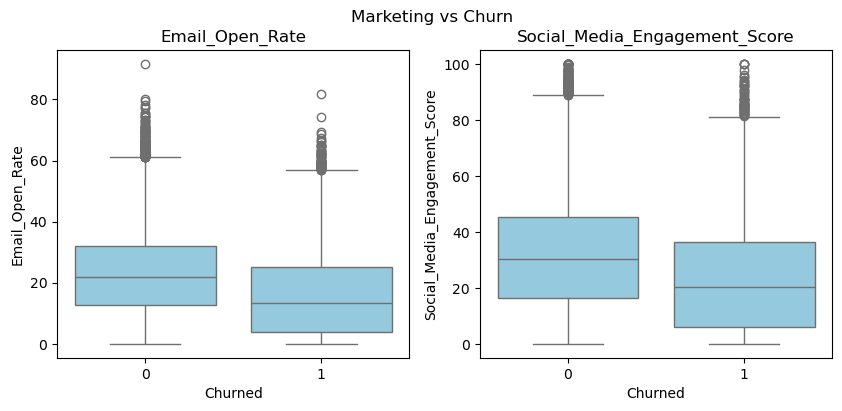

In [70]:
plt.figure(figsize=(10,4))
i = 1

for col in marketing_kpis:
    plt.subplot(1,2,i)
    sns.boxplot(data=train_df, x='Churned', y=col, color='skyblue')
    plt.title(col)
    i+=1
plt.suptitle('Marketing vs Churn')
plt.show()

9. Churn vs LTV

In [71]:
#high-value customers (top 20% LTV)
ltv_threshold = train_df['Lifetime_Value'].quantile(0.80)

train_df['High_Value_Customer'] = (train_df['Lifetime_Value'] >= ltv_threshold)
train_df.groupby('High_Value_Customer')['Churned'].mean().reset_index()

,High_Value_Customer,Churned
0,False,0.265156
1,True,0.384375


10. Average Login Frequency  - How frequently do users interact with the platform?

In [30]:
print('Logins per month:',train_df['Login_Frequency'].mean())

Logins per month: 11.639425


11. Are users deeply engaged or just visiting briefly?

In [31]:
print(df[['Session_Duration_Avg','Pages_Per_Session']].mean())

Session_Duration_Avg    27.660754
Pages_Per_Session        8.737811
dtype: float64


12. Purchase Conversion Rate  - How many customers actually buy?

In [72]:
print('Conversion Rate > 80% :',((train_df['Total_Purchases'] > 0).mean() * 100)>80)

Conversion Rate > 80% : True


13. Cart Abandonment Rate

In [33]:
print('Cart Abandonment Rate:', round(train_df['Cart_Abandonment_Rate'].mean(),2),'%')

Cart Abandonment Rate: 57.05 %


In [73]:
#high unexpected shipping, complex checkout processes, delivery

14. Wishlist to Purchase Ratio

In [34]:
train_df['Wishlist_to_Purchase_Ratio'] = train_df.apply(lambda x: x['Wishlist_Items']/x['Total_Purchases'] if x['Total_Purchases']>0 else None, axis=1)
wishlist_ratio = train_df['Wishlist_to_Purchase_Ratio'].mean()
print(f"Wishlist-to-Purchase Ratio: {wishlist_ratio:.2f}")

Wishlist-to-Purchase Ratio: 0.33


In [74]:
#Price reductions, exclusive offers, low-stock alerts, reminders

### EDA

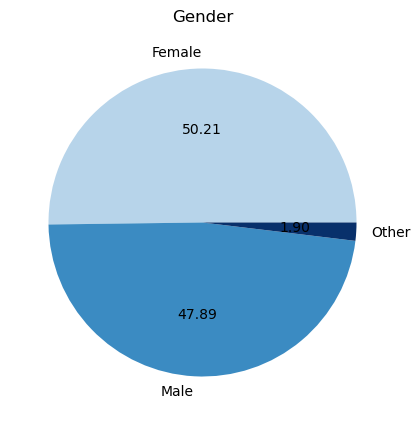

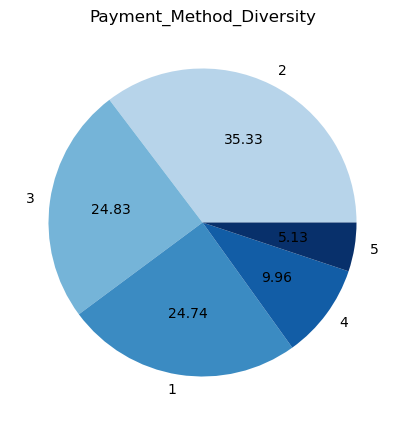

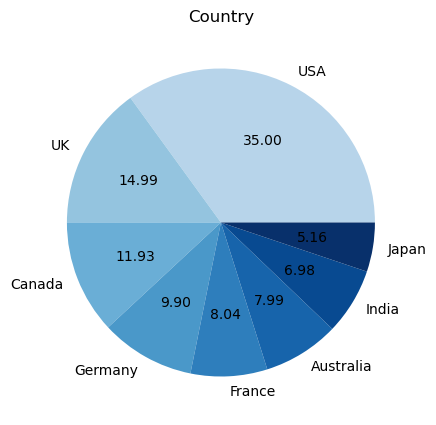

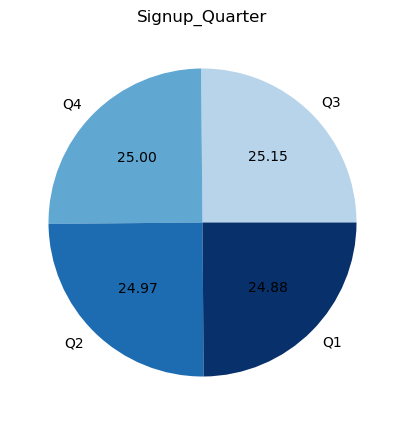

In [35]:
cols = ['Gender','Payment_Method_Diversity','Country','Signup_Quarter']

for col in cols:
    plt.figure(figsize=(5, 5))
    
    counts = train_df[col].value_counts()
    colors = plt.cm.Blues(np.linspace(0.3, 1, len(counts)))
    
    counts.plot(kind='pie', autopct='%.2f', colors=colors)
    plt.title(col)
    plt.ylabel('')
    plt.show()

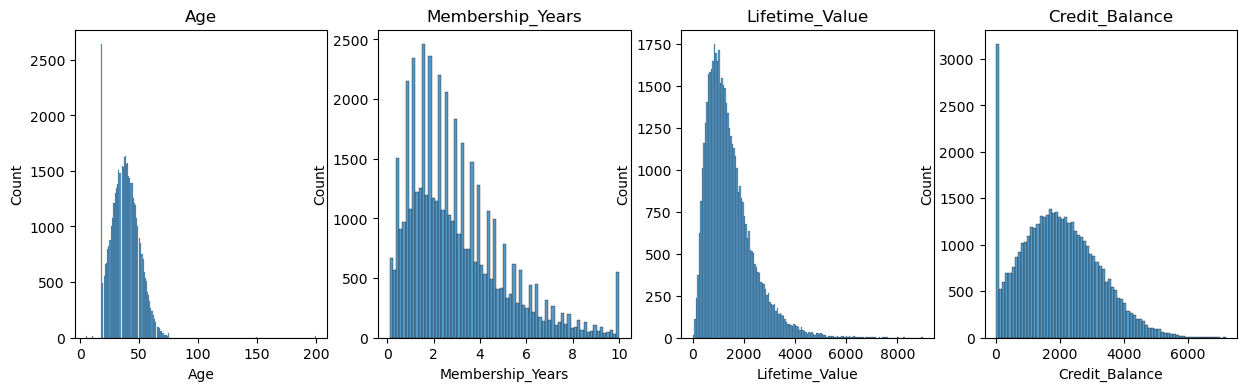

In [36]:
cols = ['Age','Membership_Years','Lifetime_Value','Credit_Balance']

plt.figure(figsize=(15,4))
i=1
for col in cols:
    plt.subplot(1,4,i)
    sns.histplot(data=train_df, x=df[col])
    plt.title(col)
    i+=1
plt.show()

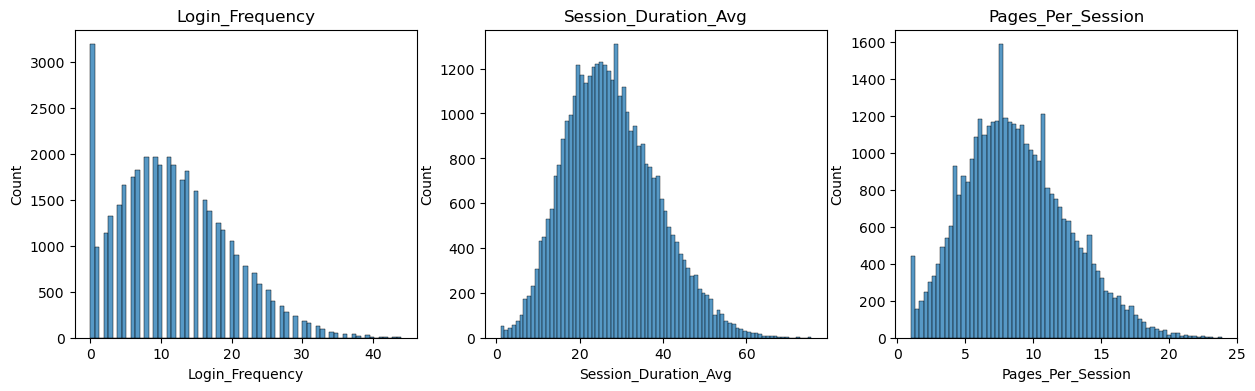

In [37]:
session = ['Login_Frequency','Session_Duration_Avg','Pages_Per_Session']
plt.figure(figsize=(15,4))
i=1
for col in session:
    plt.subplot(1,3,i)
    sns.histplot(data=train_df, x=train_df[col])
    plt.title(col)
    i+=1
plt.show()

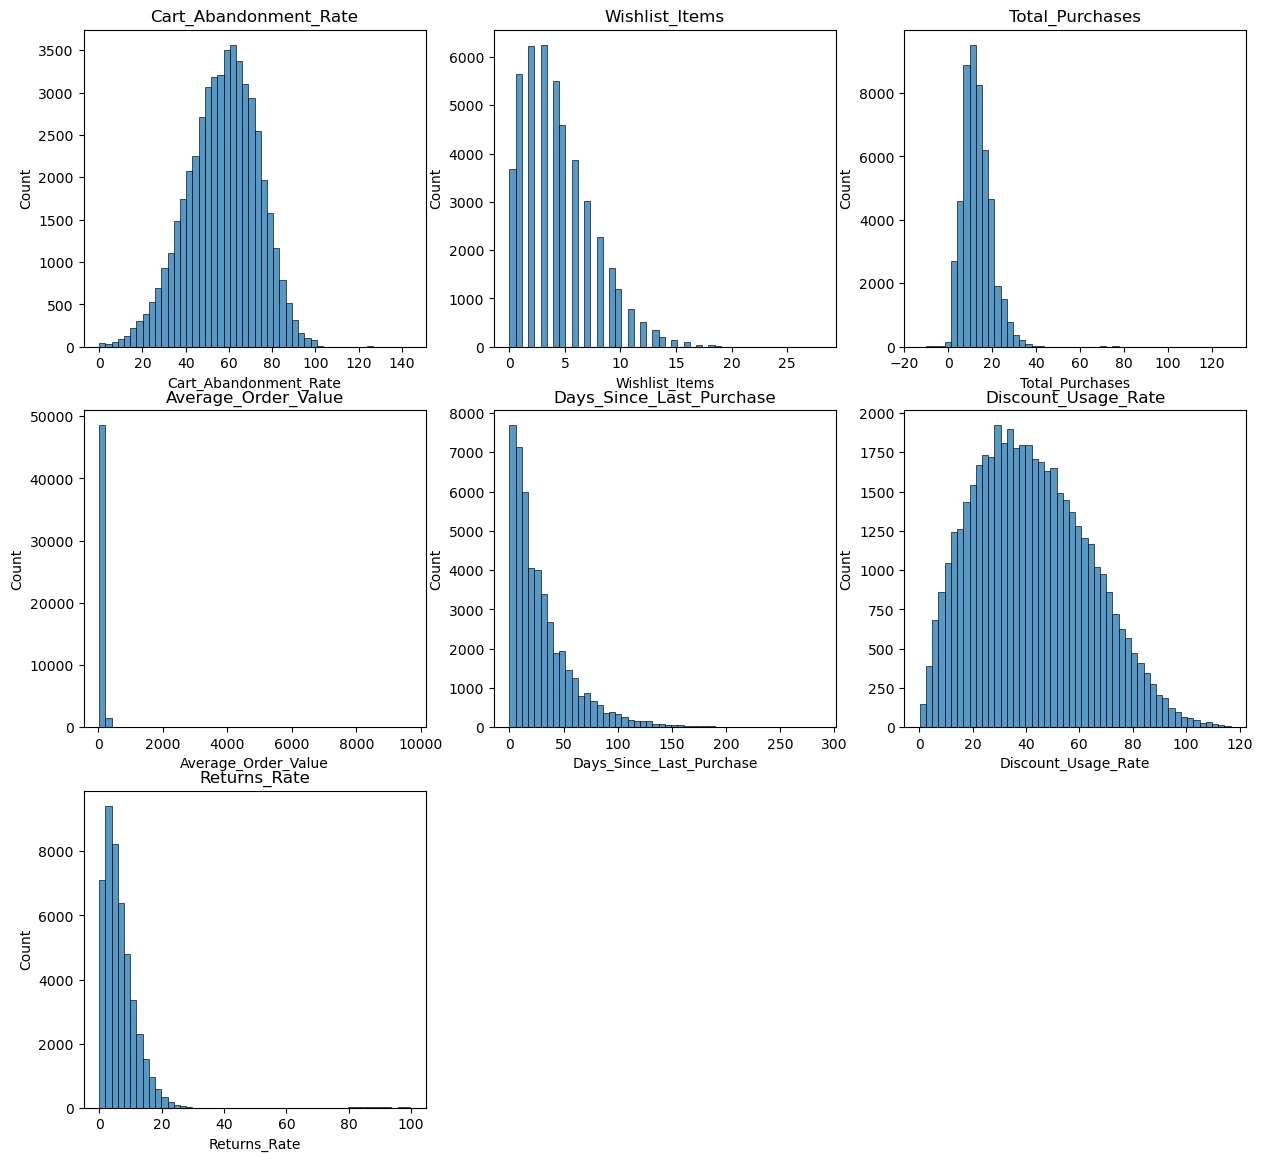

In [38]:
order = ['Cart_Abandonment_Rate','Wishlist_Items','Total_Purchases','Average_Order_Value','Days_Since_Last_Purchase','Discount_Usage_Rate','Returns_Rate']

plt.figure(figsize=(15,14))
i=1
for col in order:
    plt.subplot(3,3,i)
    sns.histplot(data=train_df, x=df[col], bins=50) 
    plt.title(col)
    i+=1
plt.show()

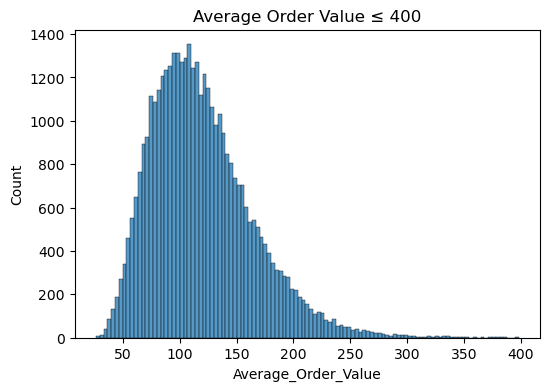

In [39]:
# since most of avg_order_value lies in (20,400) and only about 25 records are between (5000-9000)
plt.figure(figsize=(6,4))
sns.histplot(data=train_df[train_df['Average_Order_Value'] <= 400], x='Average_Order_Value')
plt.title('Average Order Value ≤ 400')
plt.show()

#### 2D

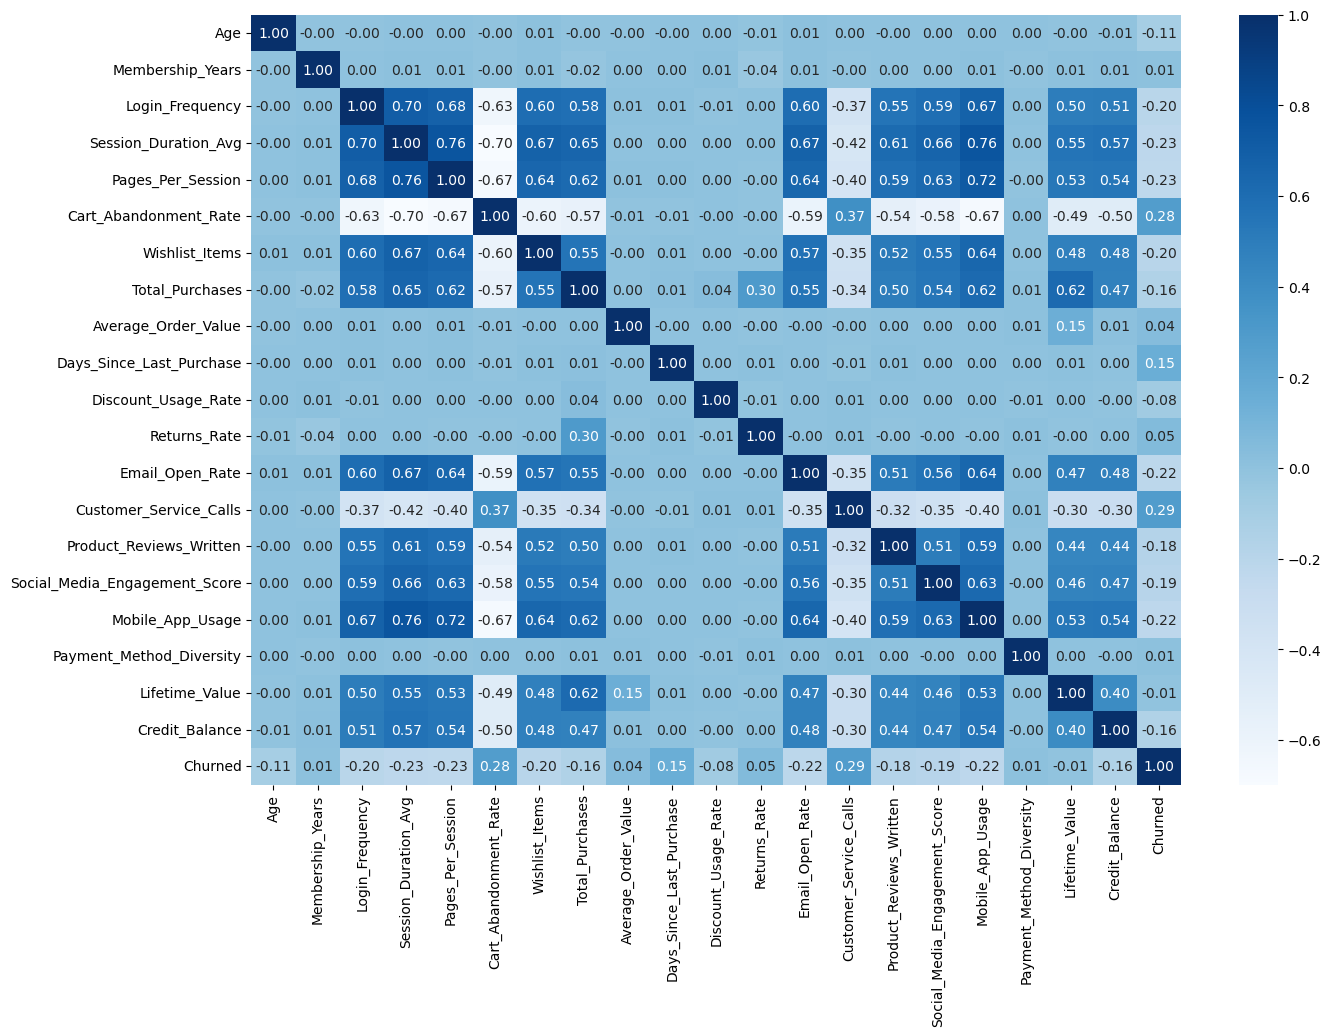

In [40]:
numeric_df = train_df.select_dtypes(include='number')
c = numeric_df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(c, annot=True, fmt=".2f", cmap='Blues')
plt.show()

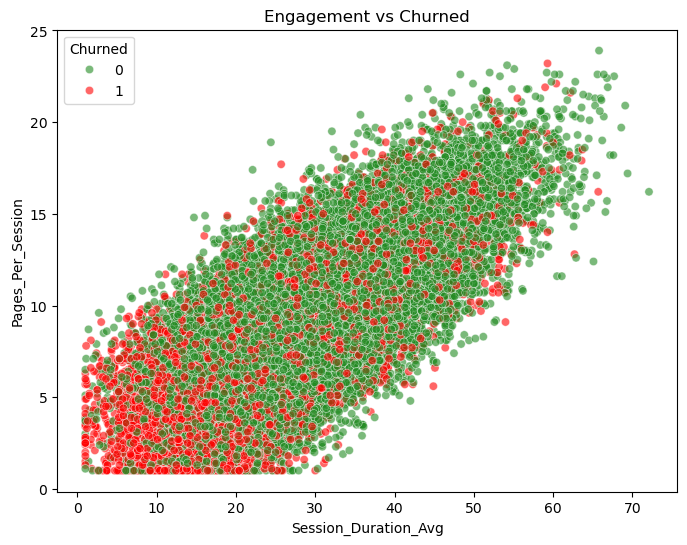

In [44]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=train_df,x='Session_Duration_Avg',y='Pages_Per_Session',hue='Churned',alpha=0.6, palette=['forestgreen','red'])
plt.title('Engagement vs Churned')
plt.show()

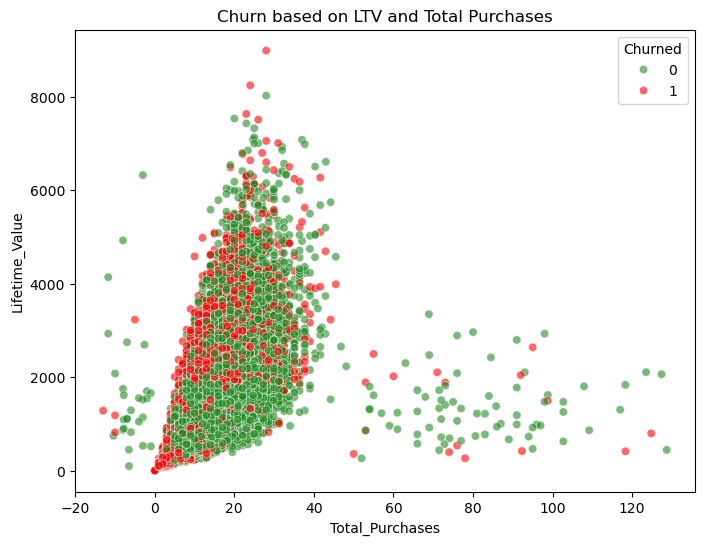

In [45]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=train_df,x='Total_Purchases',y='Lifetime_Value',hue='Churned',alpha=0.6, palette=['forestgreen','red'])
plt.title('Churn based on LTV and Total Purchases')
plt.show()

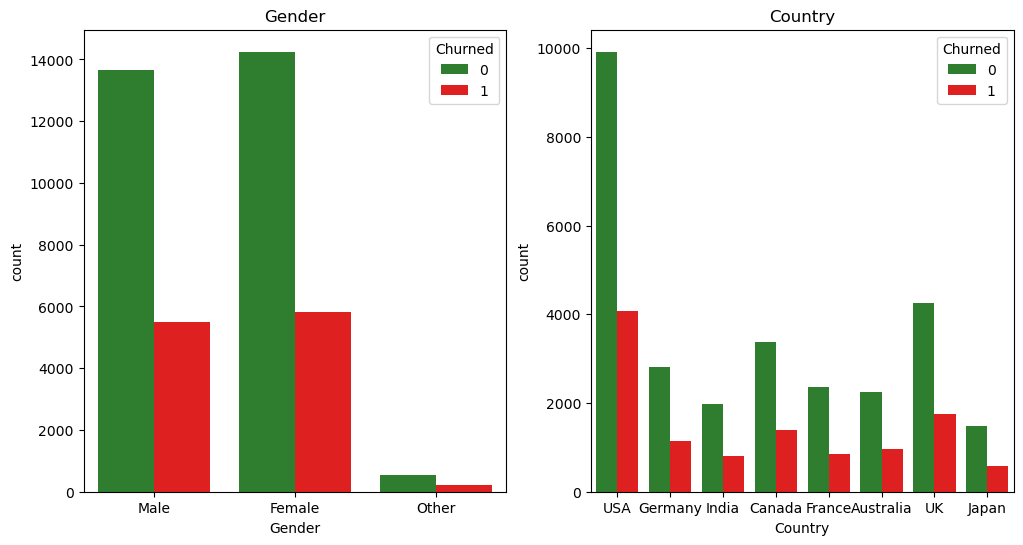

In [46]:
cols = ['Gender','Country']

plt.figure(figsize=(12,6))
i=1
for col in cols:
    plt.subplot(1,2,i)
    sns.countplot(data=train_df, x=col, hue='Churned',palette=['forestgreen','red'])
    plt.title(col)
    i+=1
plt.show()

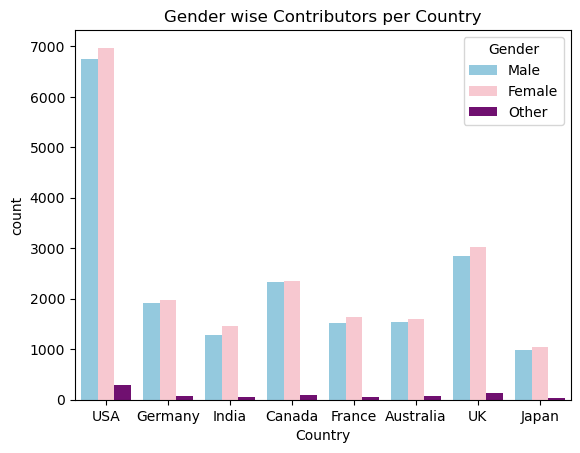

In [47]:
sns.countplot(data=train_df,x='Country',hue='Gender',palette=['Skyblue','Pink','Purple'])
plt.title('Gender wise Contributors per Country')
plt.show()

In [48]:
cols = ['Wishlist_Items','Cart_Abandonment_Rate','Total_Purchases','Email_Open_Rate','Product_Reviews_Written','Social_Media_Engagement_Score']

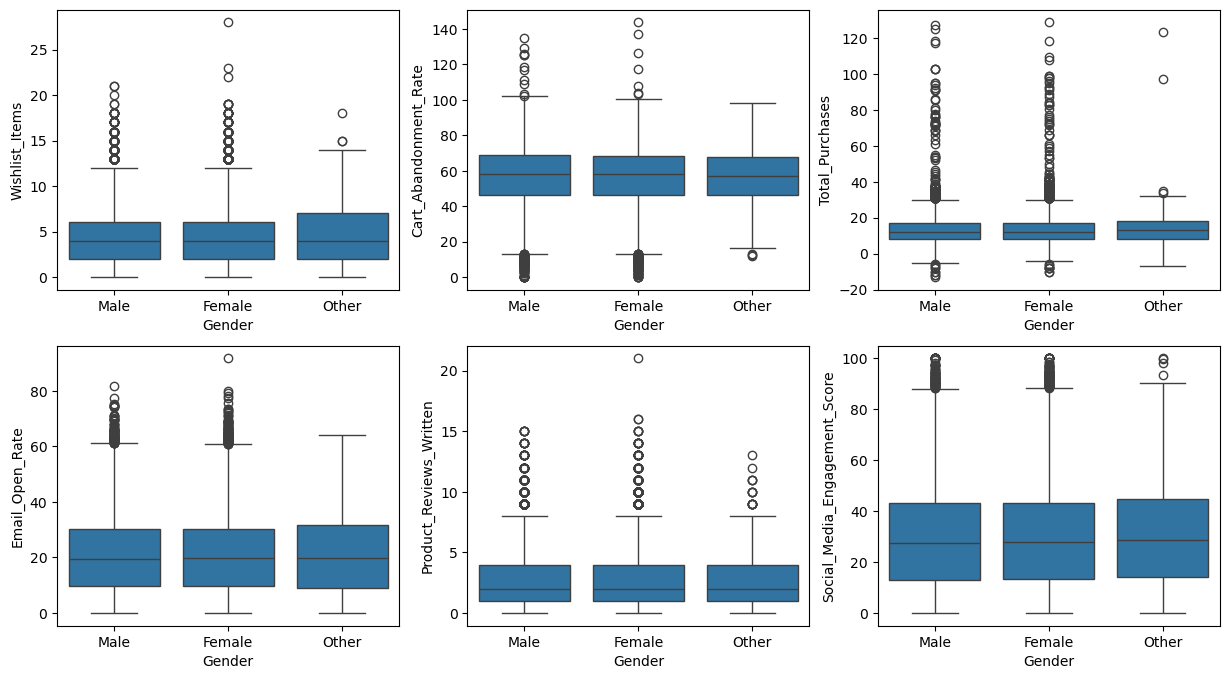

In [49]:
plt.figure(figsize=(15,8))
i=1
for col in cols:
    plt.subplot(2,3,i)
    sns.boxplot(data=train_df, x='Gender', y=col)
    i+=1
plt.show()

### Preprocessing

In [75]:
num_cols = ['Age','Membership_Years','Login_Frequency','Session_Duration_Avg','Pages_Per_Session','Cart_Abandonment_Rate',
    'Average_Order_Value','Days_Since_Last_Purchase','Discount_Usage_Rate','Returns_Rate','Email_Open_Rate','Social_Media_Engagement_Score',
    'Mobile_App_Usage','Lifetime_Value','Credit_Balance']


count_cols = ['Total_Purchases','Wishlist_Items','Customer_Service_Calls','Product_Reviews_Written','Payment_Method_Diversity']

target = ['Churned']

cat_cols = ['Gender','Country','Signup_Quarter'] 

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [52]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [53]:
count_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [54]:
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('count', count_pipeline, count_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

In [56]:
X = train_df.drop(columns=['Churned'])
y = train_df['Churned']

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        penalty = 'l2',
        random_state=42
    ))
])

In [58]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_auc_score

cm= confusion_matrix(y_pred, y_test)
print('----------Logistic Regression----------\n')
print(classification_report(y_pred, y_test))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

----------Logistic Regression----------

              precision    recall  f1-score   support

           0       0.71      0.87      0.78      5804
           1       0.73      0.51      0.60      4196

    accuracy                           0.72     10000
   macro avg       0.72      0.69      0.69     10000
weighted avg       0.72      0.72      0.70     10000

ROC-AUC: 0.7903904048588908


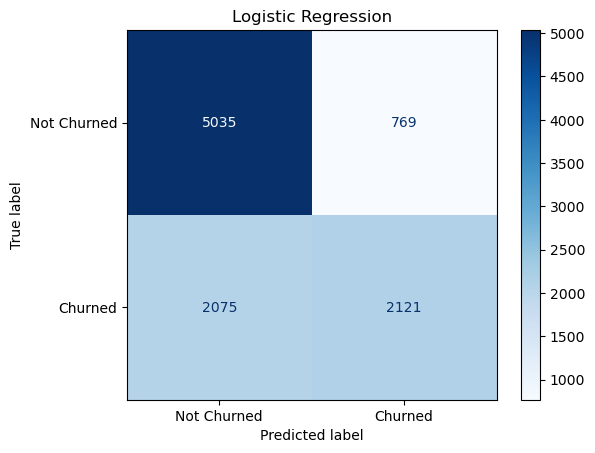

In [60]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned','Churned'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression')
plt.show()

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42
    ))
])

In [62]:
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [63]:
print('----------Random Forest----------\n')
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

----------Random Forest----------

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      7110
           1       0.81      0.84      0.82      2890

    accuracy                           0.90     10000
   macro avg       0.87      0.88      0.88     10000
weighted avg       0.90      0.90      0.90     10000

ROC-AUC: 0.9213191129020484


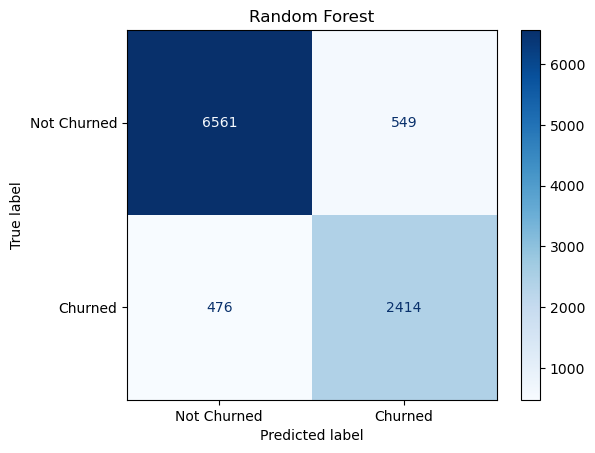

In [64]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned','Churned'])
disp.plot(cmap='Blues')
plt.title('Random Forest')
plt.show()

In [65]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("----------XGBoost----------\n")
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

----------XGBoost----------

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7110
           1       0.85      0.85      0.85      2890

    accuracy                           0.91     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.91      0.91      0.91     10000

ROC-AUC: 0.9283809051046579


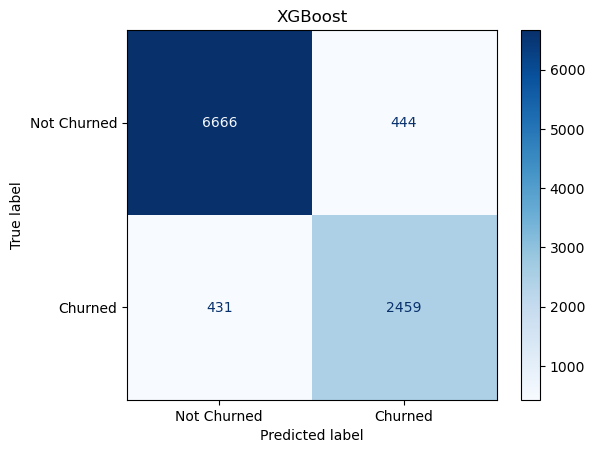

In [76]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned','Churned'])
disp.plot(cmap='Blues')
plt.title('XGBoost')
plt.show()

In [ ]:
from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        class_weight='balanced',
        random_state=42
    ))
])

lgbm_pipeline.fit(X_train, y_train)

y_pred_lgbm = lgbm_pipeline.predict(X_test)
y_prob_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

print("----------LightGBM----------\n")
print(classification_report(y_test, y_pred_lgbm))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))

In [ ]:
cm = confusion_matrix(y_test, y_pred_lgbm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned','Churned'])
disp.plot(cmap='Blues')
plt.title('LightGBM')
plt.show()

In [ ]:
from catboost import CatBoostClassifier

cat_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        verbose=0,
        class_weights=[1, (y_train == 0).sum() / (y_train == 1).sum()]
    ))
])
cat_pipeline.fit(X_train, y_train)

y_pred_cat = cat_pipeline.predict(X_test)
y_prob_cat = cat_pipeline.predict_proba(X_test)[:, 1]

print("----------CatBoost-----------\n")
print(classification_report(y_test, y_pred_cat))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_cat))

In [ ]:
cm = confusion_matrix(y_test, y_pred_cat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned','Churned'])
disp.plot(cmap='Blues')
plt.title('CatBoost')
plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'Recall (Churn)': [
        recall_score(y_test, y_pred, pos_label=1),
        recall_score(y_test, y_pred_rf, pos_label=1),
        recall_score(y_test, y_pred_xgb, pos_label=1),
        recall_score(y_test, y_pred_lgbm, pos_label=1),
        recall_score(y_test, y_pred_cat, pos_label=1)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgbm),
        roc_auc_score(y_test, y_prob_cat)
    ],
    'Precision': [
        precision_score(y_test, y_pred, pos_label=1),
        precision_score(y_test, y_pred_rf, pos_label=1),
        precision_score(y_test, y_pred_xgb, pos_label=1),
        precision_score(y_test, y_pred_lgbm, pos_label=1),
        precision_score(y_test, y_pred_cat, pos_label=1)
    ]
})

results

In [ ]:
from sklearn.metrics import precision_score
thresholds = np.arange(0.2, 0.6, 0.02)

for t in thresholds:
    y_pred_thresh = (y_prob_cat >= t).astype(int)
    recall = recall_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    print(f"Threshold {t:.2f} → Recall: {recall:.3f}, Precision: {precision:.3f}")

In [ ]:
“We catch ~89% of churners while ~70% of flagged users actually churn.”
“Lower thresholds increase recall but significantly increase false positives, which increases operational cost without proportional business benefit.”
Final Model: CatBoost Classifier
Evaluation Metric: Recall (Churn) + ROC-AUC
Decision Threshold: 0.30
Final Recall: ~0.89
Final Precision: ~0.70

In [ ]:
final_threshold = 0.30

y_pred_final = (y_prob_cat >= final_threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

In [ ]:
“Instead of using the default 0.5 decision threshold, threshold tuning was performed to optimize churn recall. A threshold of 0.30 was selected to
balance recall and precision based on business constraints.”

Higher recall in customer churn prediction is crucial because it ensures the maximum number of at-risk customers are identified before they leave,
allowing for proactive retention efforts. Since acquiring new customers is often five times more expensive than retaining existing ones, missing a 
churner (a false negative) results in significant revenue loss. 

In most businesses, churners are a minority, and standard models tend to ignore them. High recall ensures that the minority class (churners) 
is not overlooked by the model, even if this means lower precision (more false alarms).

Although a high-recall model might have lower precision (flagging loyal customers by mistake), the cost of offering a retention incentive to a 
loyal customer is often lower than the total revenue loss of missing a customer who actually churns. 

In [ ]:
“SMOTE can be useful in highly imbalanced datasets or distance-based models; however, in this study, ensemble models with class weighting achieved 
superior performance without synthetic oversampling.”

In [ ]:
# shap

In [ ]:
preprocessor = cat_pipeline.named_steps['preprocessor']
cat_model = cat_pipeline.named_steps['model']

In [ ]:
X_test_processed = preprocessor.transform(X_test)
X_train_processed = preprocessor.transform(X_train)

In [ ]:
# Numerical + count columns
num_features = num_cols + count_cols

# One-hot encoded categorical feature names
cat_features = preprocessor.named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(cat_cols)

# Combine all feature names
feature_names = list(num_features) + list(cat_features)

In [ ]:
import pandas as pd

X_test_shap = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

In [ ]:
preprocessor.named_transformers_

In [ ]:
!pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test_shap)

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    max_display=15,
    color='steelblue'
)

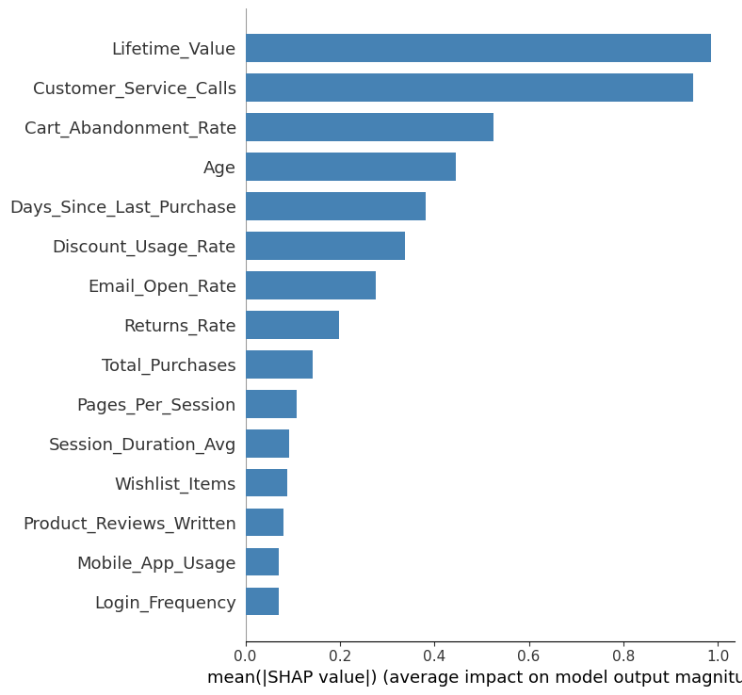

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=15
)

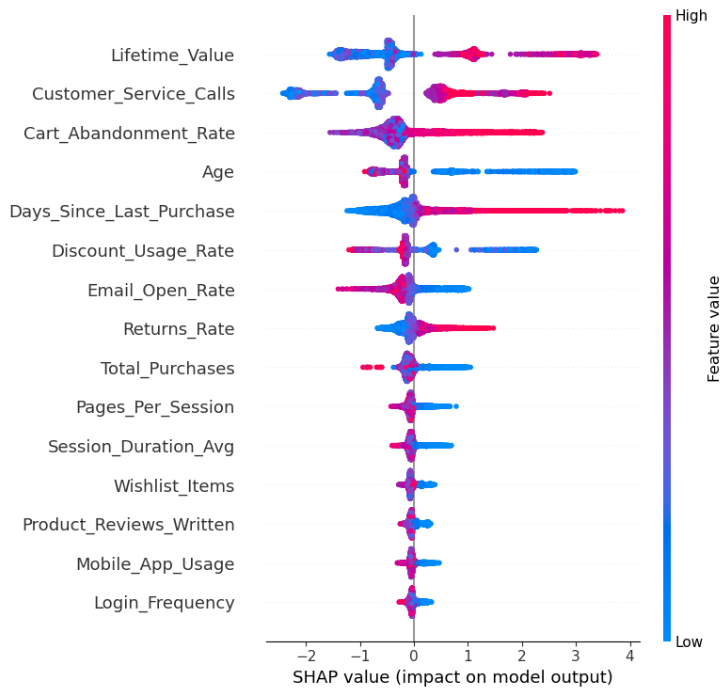

In [ ]:
customer_idx = 10
shap.force_plot(
    explainer.expected_value,
    shap_values[customer_idx],
    X_test_shap.iloc[customer_idx],
    matplotlib=True
)

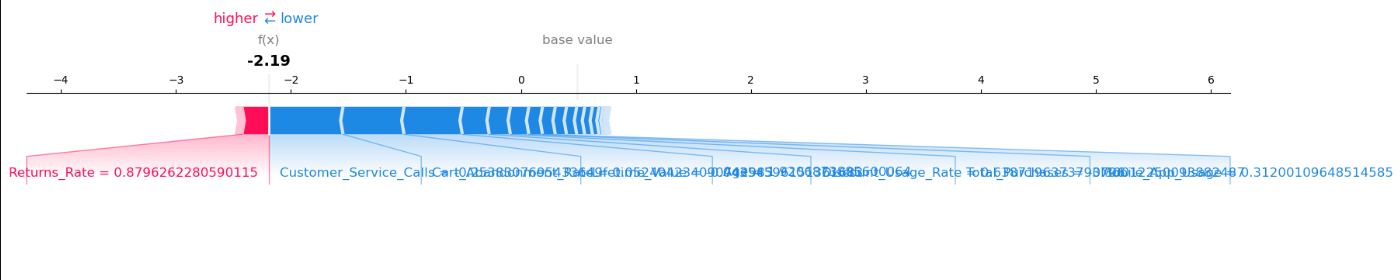

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X_test_shap.iloc[customer_idx]
    )
)

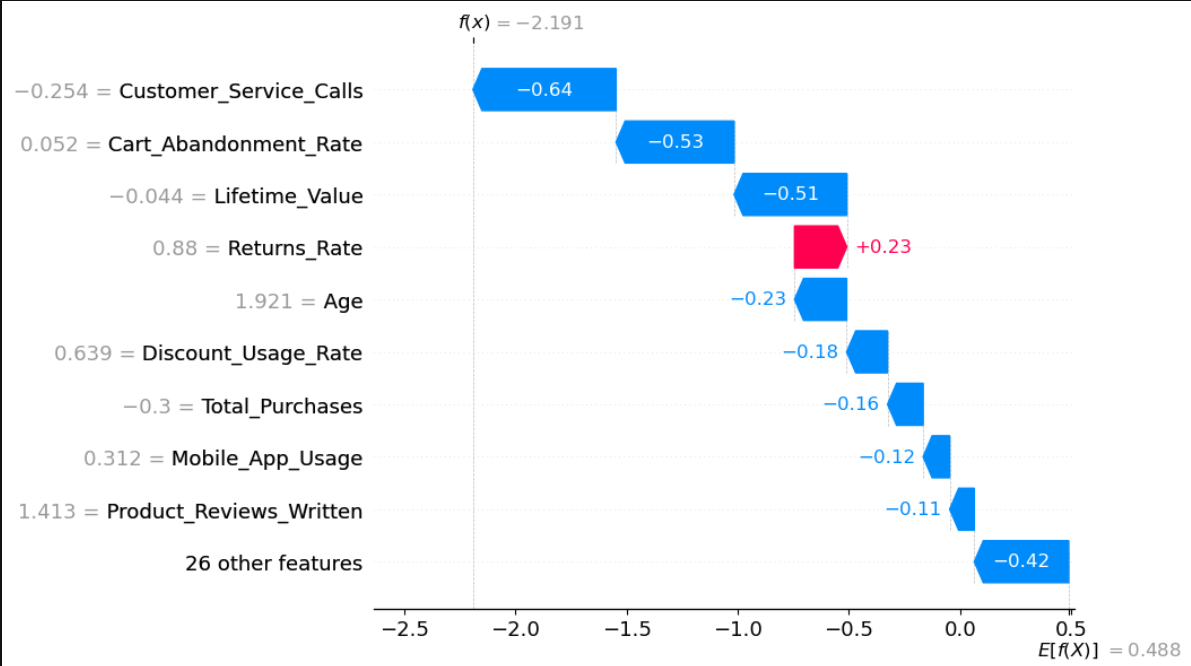